In [2]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [3]:
!pip install pyTsetlinMachineParallel -q

  Preparing metadata (setup.py) ... done


In [31]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.9 MB/s eta 0:00:00


In [39]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [40]:
import lime
import lime.lime_tabular

In [41]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from pyTsetlinMachineParallel.tm import RegressionTsetlinMachine
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import KBinsDiscretizer
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
from sklearn.inspection import permutation_importance
import pandas as pd

In [43]:

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

In [44]:
import shap

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [45]:
df = pd.read_csv("/content/drive/MyDrive/Forecasting-Agent-for-Fintech/data/macro/combined_macro_data.csv", parse_dates=["date"])

In [46]:
df = df.drop(columns=['gdp'])

In [47]:
def get_model(model_name):
    models = {
        'RF':       RandomForestRegressor(
                        n_estimators=500, max_depth=5,
                        min_samples_leaf=3, random_state=42),
        'GB':       GradientBoostingRegressor(
                        n_estimators=300, learning_rate=0.05,
                        max_depth=3, min_samples_leaf=3,
                        subsample=0.8, random_state=42),
        'XGB':      XGBRegressor(
                        n_estimators=500, learning_rate=0.03,
                        max_depth=3, subsample=0.7,
                        colsample_bytree=0.7, reg_alpha=0.1,
                        reg_lambda=1.0, random_state=42,
                        objective='reg:squarederror'),
        'KNN':      KNeighborsRegressor(n_neighbors=7, weights='distance'),
        'SVR':      SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
        'bayes':    BayesianRidge(max_iter=500),
        'catboost': CatBoostRegressor(
                        iterations=500, learning_rate=0.03, depth=4,
                        l2_leaf_reg=5.0, random_state=42, verbose=0)
    }
    return models[model_name]


In [48]:

PARAM_GRIDS = {
    'RF': {
        'model__n_estimators':      [300, 500, 800],
        'model__max_depth':         [3, 5, 7, None],
        'model__min_samples_leaf':  [2, 3, 5],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features':      ['sqrt', 0.5, 0.7],
    },
    'GB': {
        'model__n_estimators':     [200, 300, 500],
        'model__learning_rate':    [0.01, 0.03, 0.05, 0.1],
        'model__max_depth':        [2, 3, 4],
        'model__subsample':        [0.6, 0.7, 0.8],
        'model__min_samples_leaf': [2, 3, 5],
    },
    'XGB': {
        'model__n_estimators':     [300, 500, 800],
        'model__learning_rate':    [0.01, 0.03, 0.05],
        'model__max_depth':        [2, 3, 4],
        'model__subsample':        [0.6, 0.7, 0.8],
        'model__colsample_bytree': [0.6, 0.7, 0.8],
        'model__reg_alpha':        [0.0, 0.1, 0.5, 1.0],
        'model__reg_lambda':       [0.5, 1.0, 2.0],
        'model__min_child_weight': [1, 3, 5],
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 10, 15],
        'model__weights':     ['uniform', 'distance'],
        'model__metric':      ['euclidean', 'manhattan'],
        'model__leaf_size':   [20, 30, 40],
    },
    'SVR': {
        'model__C':       [0.1, 1.0, 10.0, 50.0, 100.0],
        'model__epsilon': [0.001, 0.01, 0.05, 0.1],
        'model__gamma':   ['scale', 'auto', 0.01, 0.1],
        'model__kernel':  ['rbf', 'linear'],
    },
    'bayes': {
        'model__alpha_1':  [1e-7, 1e-6, 1e-5],
        'model__alpha_2':  [1e-7, 1e-6, 1e-5],
        'model__lambda_1': [1e-7, 1e-6, 1e-5],
        'model__lambda_2': [1e-7, 1e-6, 1e-5],
        'model__max_iter': [300, 500, 1000],
    },
    'catboost': {
        'model__iterations':    [300, 500, 800],
        'model__learning_rate': [0.01, 0.03, 0.05],
        'model__depth':         [3, 4, 5, 6],
        'model__l2_leaf_reg':   [1.0, 3.0, 5.0, 10.0],
        'model__subsample':     [0.6, 0.7, 0.8],
    },
}

BASE_MODELS = {
    'RF':       RandomForestRegressor(random_state=42, n_jobs=-1),
    'GB':       GradientBoostingRegressor(random_state=42),
    'XGB':      XGBRegressor(random_state=42, objective='reg:squarederror',
                             tree_method='hist', verbosity=0),
    'KNN':      KNeighborsRegressor(),
    'SVR':      SVR(),
    'bayes':    BayesianRidge(),
    'catboost': CatBoostRegressor(random_state=42, verbose=0),
}

In [49]:

def tune_model(model_name, pre_steps, X_train, y_train,
               n_iter=30, cv_splits=5):
    steps  = pre_steps + [('model', BASE_MODELS[model_name])]
    pipe   = Pipeline(steps)
    tscv   = TimeSeriesSplit(n_splits=cv_splits)
    search = RandomizedSearchCV(
        estimator          = pipe,
        param_distributions= PARAM_GRIDS[model_name],
        n_iter             = n_iter,
        cv                 = tscv,
        scoring            = 'r2',
        random_state       = 42,
        n_jobs             = -1,
        refit              = True
    )
    search.fit(X_train, y_train)
    print(f"  Best CV R²:  {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    return search.best_estimator_

In [50]:

def tune_tsetlin_optuna(X_train, y_train, n_bins_fixed,
                        n_trials=30, cv_splits=3):
    binner   = KBinsDiscretizer(n_bins=n_bins_fixed, encode='ordinal',
                                strategy='quantile')
    X_binned = binner.fit_transform(X_train).astype(np.int32)

    y_scale  = np.abs(y_train).max()
    if y_scale == 0:
        y_scale = 1.0
    y_arr    = (np.array(y_train, dtype=np.float32) / y_scale * 1000)
    tscv     = TimeSeriesSplit(n_splits=cv_splits)

    def objective(trial):
        clauses = trial.suggest_categorical('number_of_clauses', [200, 500, 1000, 2000, 4000])
        T       = trial.suggest_categorical('T', [50, 100, 200, 500, 1000])
        s       = trial.suggest_float('s', 1.5, 10.0)
        epochs  = trial.suggest_categorical('epochs', [20, 50, 100, 200])
        n_bins  = trial.suggest_int('n_bins', 5, 25)

        fold_r2s = []
        for train_idx, val_idx in tscv.split(X_binned):
            X_tr_raw = X_train[train_idx]
            X_val_raw= X_train[val_idx]
            y_tr     = np.array(y_train)[train_idx]
            y_val    = np.array(y_train)[val_idx]
            try:
                b2        = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
                X_tr_b    = b2.fit_transform(X_tr_raw).astype(np.int32)
                X_val_b   = b2.transform(X_val_raw).astype(np.int32)
                y_sc      = np.abs(y_tr).max()
                if y_sc == 0: y_sc = 1.0
                y_tr_sc   = (y_tr / y_sc * 1000).astype(np.float32)
                tm        = RegressionTsetlinMachine(number_of_clauses=clauses, T=T, s=s)
                tm.fit(X_tr_b, y_tr_sc, epochs=epochs)
                preds_sc  = tm.predict(X_val_b).astype(np.float64)
                preds     = preds_sc / 1000 * y_sc
                fold_r2s.append(r2_score(y_val, preds))
            except Exception:
                fold_r2s.append(-999)
        mean_r2 = np.mean(fold_r2s)
        return mean_r2 if np.isfinite(mean_r2) else -999

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"  Best Optuna CV R²: {study.best_value:.4f}")
    print(f"  Best params:       {study.best_params}")
    return study.best_params, binner



In [51]:
def add_lag_features(X_df, lag_cols, lags=[1, 2, 4]):
    X = X_df.copy()
    for col in lag_cols:
        if col in X.columns:
            for lag in lags:
                X[f"{col}_lag{lag}"] = X[col].shift(lag)
    return X

In [52]:
def add_rolling_features(X_df, roll_cols, windows=[2, 4]):
    X = X_df.copy()
    for col in roll_cols:
        if col in X.columns:
            for w in windows:
                X[f"{col}_roll{w}"] = X[col].shift(1).rolling(w).mean()
    return X

In [53]:
def standard_importance(fitted_model, pipeline, X_train, y_train, feature_names):
    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm        = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=10, random_state=42)
        importances = perm.importances_mean
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)


In [54]:
def shap_importance(fitted_model, X_train, feature_names):
    X_train_df  = pd.DataFrame(X_train, columns=feature_names)
    tree_models = (RandomForestRegressor, GradientBoostingRegressor,
                   XGBRegressor, CatBoostRegressor)
    if isinstance(fitted_model, tree_models):
        explainer   = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_train_df)
    else:
        explainer   = shap.KernelExplainer(
            fitted_model.predict, shap.sample(X_train_df, 50))
        shap_values = explainer.shap_values(X_train_df)
    importances = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True), shap_values, X_train_df


In [55]:
def permutation_importance_ranked(pipeline, X_train, y_train, feature_names):
    perm = permutation_importance(pipeline, X_train, y_train,
                                  n_repeats=20, random_state=42)
    return pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)


In [56]:
def plot_macro_bar(fi_df, title):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [57]:
def plot_permutation(fi_df, model_name):
    fig, ax = plt.subplots(figsize=(7, max(4, len(fi_df) * 0.35)))
    top = fi_df.head(20)
    ax.barh(top['feature'][::-1], top['importance'][::-1],
            xerr=top['std'][::-1] if 'std' in top.columns else None,
            color='mediumseagreen', capsize=3)
    ax.set_title(f"Permutation Importance — Top 20\n({model_name})")
    ax.set_xlabel("Mean accuracy decrease (±std)")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [58]:
def plot_shap(shap_values, X_train_df, model_name):
    plt.figure()
    shap.summary_plot(shap_values, X_train_df, plot_type="bar", show=False)
    plt.title(f"SHAP — Mean |SHAP| ({model_name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_train_df, show=False)
    plt.title(f"SHAP — Direction & Magnitude ({model_name})")
    plt.tight_layout()
    plt.show()


In [59]:

def lime_importance(fitted_model, X_train, X_test, feature_names, model_name):
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_test_df  = pd.DataFrame(X_test,  columns=feature_names)

    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data        = X_train,
        feature_names        = feature_names,
        mode                 = 'regression',
        discretize_continuous= True,
        random_state         = 42
    )

    all_weights = []
    for i in range(len(X_test)):
        exp          = explainer.explain_instance(
            X_test[i],
            fitted_model.predict,
            num_features = len(feature_names),
            num_samples  = 500
        )
        weights_dict = dict(exp.as_list())
        row          = {f: 0.0 for f in feature_names}
        for key, val in weights_dict.items():
            for fname in feature_names:
                if fname in key:
                    row[fname] = val
                    break
        all_weights.append(row)

    lime_df = pd.DataFrame(all_weights)

    fi_lime = pd.DataFrame({
        'feature':     feature_names,
        'importance':  lime_df.abs().mean().values,
        'mean_effect': lime_df.mean().values,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(fi_lime.head(20)) * 0.35)))

    top = fi_lime.head(20)
    axes[0].barh(top['feature'][::-1], top['importance'][::-1], color='mediumpurple')
    axes[0].set_title(f"LIME — Mean |Weight| ({model_name})")
    axes[0].set_xlabel("Mean Absolute LIME Weight")
    axes[0].grid(True, alpha=0.3)

    colors = ['tomato' if v < 0 else 'steelblue' for v in top['mean_effect'][::-1]]
    axes[1].barh(top['feature'][::-1], top['mean_effect'][::-1], color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title(f"LIME — Direction of Effect ({model_name})\nBlue=increases GDP, Red=decreases GDP")
    axes[1].set_xlabel("Mean Signed LIME Weight")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"LIME Feature Importance — {model_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return fi_lime


In [60]:

def compute_and_plot_importance(strategy, fitted_model, pipeline,
                                X_train, y_train, feature_names, model_name,
                                X_test=None):
    run_standard    = strategy in ('standard',    'all')
    run_shap        = strategy in ('shap',        'all')
    run_permutation = strategy in ('permutation', 'all')
    run_lime        = strategy in ('lime',        'all')

    fi_standard = fi_shap = fi_perm = fi_lime = None

    if run_standard:
        fi_standard = standard_importance(fitted_model, pipeline,
                                          X_train, y_train, feature_names)
        plot_macro_bar(fi_standard, f"Standard Importance — All Macro\n({model_name})")

    if run_shap:
        fi_shap, shap_values, X_train_df = shap_importance(fitted_model, X_train, feature_names)
        plot_shap(shap_values, X_train_df, model_name)

    if run_permutation:
        fi_perm = permutation_importance_ranked(pipeline, X_train, y_train, feature_names)
        plot_permutation(fi_perm, model_name)

    if run_lime:
        if X_test is not None:
            fi_lime = lime_importance(fitted_model, X_train, X_test,
                                      feature_names, model_name)
        else:
            print("LIME skipped — X_test not passed to compute_and_plot_importance")

    return fi_standard, fi_shap, fi_perm, fi_lime


In [61]:
def run_arima(y_train, y_test, test_dates, X_train=None, X_test=None, use_macro=False):
    exog_train = X_train if use_macro and X_train is not None else None
    exog_test  = X_test  if use_macro and X_test  is not None else None

    best_result = None
    best_aic    = np.inf

    for p in [1, 2, 4]:
        for d in [0, 1]:
            for q in [0, 1]:
                try:
                    m = SARIMAX(y_train, exog=exog_train,
                                order=(p, d, q),
                                seasonal_order=(1, 0, 0, 4),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best_aic    = m.aic
                        best_result = m
                except Exception:
                    continue

    predictions = np.array(best_result.forecast(steps=len(y_test), exog=exog_test))
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100

    results = pd.DataFrame({
        "date":          test_dates.values,
        "gdp_growth":    y_test.values,
        "predicted_gdp": predictions
    })

    print(f"\n{'='*65}")
    print(f"ARIMA — Best order AIC: {best_aic:.2f}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['gdp_growth'] - row['predicted_gdp'])
        print(f"{str(row['date'])[:10]:<15} {row['gdp_growth']:>12.2f} {row['predicted_gdp']:>12.2f} {error:>12.2f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.4f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")
    print("\nNote: ARIMA feature importance not applicable — AR/MA coefficients:")
    print(best_result.params)

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["gdp_growth"],    marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["predicted_gdp"], marker="o", label="Predicted", linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("GDP")
    ax.set_title(f"GDP Prediction — ARIMA\n(R²={r2:.3f}  RMSE={rmse:.4f}  MAPE={mape:.1f}%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results, rmse, mape, r2


In [62]:

def run_tsetlin(X_train, X_test, y_train, y_test, test_dates,
                feature_names, importance_strategy,
                n_bins=10, epochs=30, tune=True, n_trials=30):
    if tune:
        print("\nRunning Optuna tuning for Tsetlin Machine (GDP)...")
        best_params, binner = tune_tsetlin_optuna(
            X_train, y_train,
            n_bins_fixed = n_bins,
            n_trials     = n_trials
        )
        number_of_clauses = best_params['number_of_clauses']
        T                 = best_params['T']
        s                 = best_params['s']
        epochs            = best_params['epochs']
        n_bins            = best_params.get('n_bins', n_bins)
    else:
        binner            = KBinsDiscretizer(n_bins=n_bins, encode='ordinal',
                                             strategy='quantile')
        binner.fit(X_train)
        number_of_clauses = 1000
        T                 = 200
        s                 = 2.75

    X_tr_b = binner.transform(X_train).astype(np.int32)
    X_te_b = binner.transform(X_test).astype(np.int32)

    y_scale = np.abs(np.array(y_train)).max()
    if y_scale == 0: y_scale = 1.0
    y_tr_sc = (np.array(y_train, dtype=np.float32) / y_scale * 1000)

    tm = RegressionTsetlinMachine(number_of_clauses=number_of_clauses, T=T, s=s)
    tm.fit(X_tr_b, y_tr_sc, epochs=epochs)

    preds_sc    = tm.predict(X_te_b).astype(np.float64)
    predictions = preds_sc / 1000 * y_scale
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100

    results = pd.DataFrame({
        "date":           test_dates.values,
        "gdp_growth":     y_test.values,
        "predicted_gdp":  predictions
    })

    print(f"\n{'='*65}")
    print(f"Tsetlin Machine — GDP {'(Tuned)' if tune else '(Default)'}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['gdp_growth'] - row['predicted_gdp'])
        print(f"{str(row['date'])[:10]:<15} {row['gdp_growth']:>12.2f} {row['predicted_gdp']:>12.2f} {error:>12.2f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.4f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")

    fig, ax = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax.plot(x, results["gdp_growth"],   marker="o", label="Actual",    linewidth=2)
    ax.plot(x, results["predicted_gdp"], marker="o", label="Predicted", linewidth=2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("GDP")
    ax.set_title(f"GDP Prediction — Tsetlin\n(R²={r2:.3f}  RMSE={rmse:.4f}  MAPE={mape:.1f}%)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    class _TsetlinWrapper:
        def fit(self_, X, y):   return self_
        def predict(self_, X):
            raw = tm.predict(binner.transform(X).astype(np.int32)).astype(np.float64)
            return raw / 1000 * y_scale
        def score(self_, X, y): return r2_score(y, self_.predict(X))

    perm    = permutation_importance(_TsetlinWrapper(), X_train, y_train,
                                     n_repeats=10, random_state=42, scoring='r2')
    fi_perm = pd.DataFrame({
        'feature':    feature_names,
        'importance': perm.importances_mean,
        'std':        perm.importances_std
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    plot_permutation(fi_perm, "Tsetlin")
    return results, rmse, mape, r2, fi_perm



In [65]:

def GDP_prediction(data, use_macro, model,
                   use_scaling, test_quarters=8,
                   use_lags=True, use_rolling=True,
                   feature_selection=False, n_features=15,
                   importance_strategy='standard',
                   tune=True, n_iter=30, cv_splits=5):

    macro_vars = [
        "b30ret","b20ret","b10ret","b7ret","b5ret","b2ret","b1ret",
        "t90ret","t30ret","cpiret","wti_price","fedfunds","nfci","anfci",
        "nfci_risk","nfci_credit","nfci_leverage","nfci_nonfinancial_leverage",
        "ppi","trade_balance","unrate","usd_index"
    ]

    df = data.copy().sort_values("date").reset_index(drop=True)

    if use_lags:
        for lag in [1, 2, 4]:
            df[f"gdp_lag{lag}"] = df["gdp_growth"].shift(lag)
        for col in macro_vars:
            if col in df.columns:
                df[f"{col}_lag1"] = df[col].shift(1)

    if use_rolling:
        for w in [2, 4]:
            df[f"gdp_roll{w}"] = df["gdp_growth"].shift(1).rolling(w).mean()

    df = df.dropna().reset_index(drop=True)
    dates = df["date"]

    X = df.drop(columns=["gdp_growth", "date"])
    y = df["gdp_growth"]

    X_train       = X.iloc[:-test_quarters]
    X_test        = X.iloc[-test_quarters:]
    y_train       = y.iloc[:-test_quarters]
    y_test        = y.iloc[-test_quarters:]
    test_dates    = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()

    if model == 'arima':
        return run_arima(
            y_train   = y_train,
            y_test    = y_test,
            test_dates= test_dates,
            X_train   = X_train.values if use_macro else None,
            X_test    = X_test.values  if use_macro else None,
            use_macro = use_macro
        )

    if model == 'tsetlin':
        return run_tsetlin(
            X_train             = X_train.values,
            X_test              = X_test.values,
            y_train             = y_train,
            y_test              = y_test,
            test_dates          = test_dates,
            feature_names       = feature_names,
            importance_strategy = importance_strategy,
            tune                = tune,
            n_trials            = n_iter
        )

    print(f"Total: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_names)}")

    pre_steps = []
    if use_scaling:
        pre_steps.append(('scaler', RobustScaler()))
    if feature_selection:
        pre_steps.append(('selector', SelectKBest(f_regression,
                                                   k=min(n_features, X.shape[1]))))

    if tune and model in PARAM_GRIDS:
        print(f"\nTuning {model} with TimeSeriesSplit (n_iter={n_iter}, cv={cv_splits})...")
        pipeline = tune_model(model, pre_steps, X_train, y_train,
                              n_iter=n_iter, cv_splits=cv_splits)
    else:
        pre_steps.append(('model', get_model(model)))
        pipeline = Pipeline(pre_steps)
        pipeline.fit(X_train, y_train)

    predictions  = pipeline.predict(X_test)
    fitted_model = pipeline.named_steps['model']

    mse  = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100

    results = pd.DataFrame({
        "date":          test_dates.values,
        "gdp_growth":    y_test.values,
        "predicted_gdp": predictions
    })

    print(f"\n{'='*65}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*65}")
    for _, row in results.iterrows():
        error = abs(row['gdp_growth'] - row['predicted_gdp'])
        print(f"{str(row['date'])[:10]:<15} {row['gdp_growth']:>12.2f} {row['predicted_gdp']:>12.2f} {error:>12.2f}")
    print(f"{'-'*65}")
    print(f"{'RMSE:':>45} {rmse:>12.4f}")
    print(f"{'MAPE (%):':>45} {mape:>12.2f}")
    print(f"{'R²:':>45} {r2:>12.4f}")
    print(f"{'='*65}")

    if feature_selection:
        selected_mask   = pipeline.named_steps['selector'].get_support()
        feat_names_used = [f for f, s in zip(feature_names, selected_mask) if s]
        X_train_arr     = pipeline[:-1].transform(X_train)
    else:
        feat_names_used = feature_names
        X_train_arr     = pipeline[:-1].transform(X_train) if use_scaling else X_train.values

    fig_pred, ax_pred = plt.subplots(figsize=(10, 4))
    x = range(len(results))
    ax_pred.plot(x, results["gdp_growth"],   marker="o", label="Actual",    linewidth=2)
    ax_pred.plot(x, results["predicted_gdp"], marker="o", label="Predicted", linewidth=2)
    ax_pred.set_xticks(x)
    ax_pred.set_xticklabels([str(d)[:10] for d in results["date"]], rotation=45)
    ax_pred.set_xlabel("Quarter")
    ax_pred.set_ylabel("GDP")
    tuned_label = "Tuned" if tune else "Default"
    ax_pred.set_title(f"GDP Prediction — {model} ({tuned_label})\n(R²={r2:.3f}  RMSE={rmse:.4f}  MAPE={mape:.1f}%)")
    ax_pred.legend()
    ax_pred.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    X_test_arr = pipeline[:-1].transform(X_test) if use_scaling else X_test.values

    fi_standard, fi_shap, fi_perm, fi_lime = compute_and_plot_importance(
        strategy      = importance_strategy,
        fitted_model  = fitted_model,
        pipeline      = pipeline,
        X_train       = X_train_arr,
        y_train       = y_train,
        feature_names = feat_names_used,
        model_name    = model,
        X_test        = X_test_arr
    )

    return results, rmse, mape, r2, fi_standard, fi_shap, fi_perm, fi_lime


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


ARIMA — Best order AIC: -939.61
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.02         0.01
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.01         0.01
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.02         0.01
-----------------------------------------------------------------
                                        RMSE:       0.0043
                                    MAPE (%):        27.89
                                          R²:      -0.8452

Note: ARIMA feature importance not applicable — AR/MA coefficients:
x1         6.648030e-02
x2        -7.049150e-02
x3        -1.059019e-01
x4         7.236338e-0

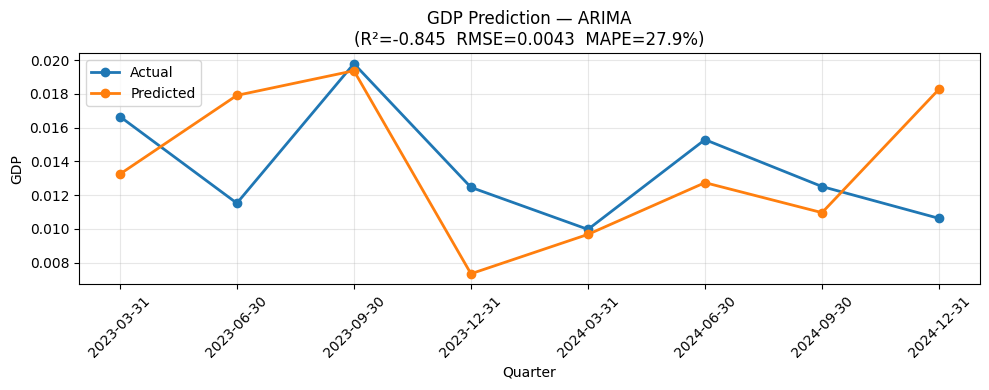

In [67]:
results, rmse, mape, r2= GDP_prediction(
    df,
    use_macro=True,
    model='arima',
    use_scaling=True,
    test_quarters=8,
    feature_selection=False,
    importance_strategy='lime',
    tune=True, n_iter=30, cv_splits=5
)


Running Optuna tuning for Tsetlin Machine (GDP)...


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 43 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 43 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 43 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 43 are removed. Consider decreasing the number of bins.
  warnings.warn(


  Best Optuna CV R²: -0.0135
  Best params:       {'number_of_clauses': 500, 'T': 100, 's': 6.05362763635098, 'epochs': 100, 'n_bins': 11}

Tsetlin Machine — GDP (Tuned)
Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02        -0.00         0.02
2023-06-30              0.01        -0.01         0.02
2023-09-30              0.02         0.00         0.02
2023-12-31              0.01        -0.01         0.02
2024-03-31              0.01         0.00         0.01
2024-06-30              0.02        -0.01         0.02
2024-09-30              0.01        -0.01         0.03
2024-12-31              0.01        -0.01         0.02
-----------------------------------------------------------------
                                        RMSE:       0.0206
                                    MAPE (%):       151.93
                                          R²:     -41.8093


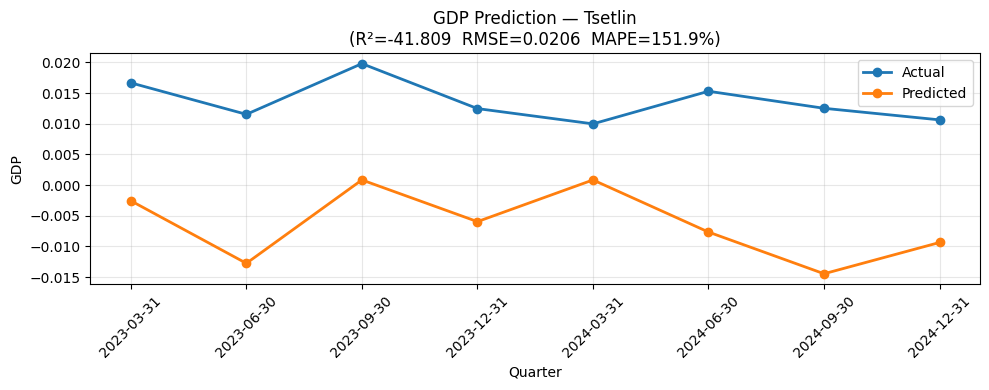

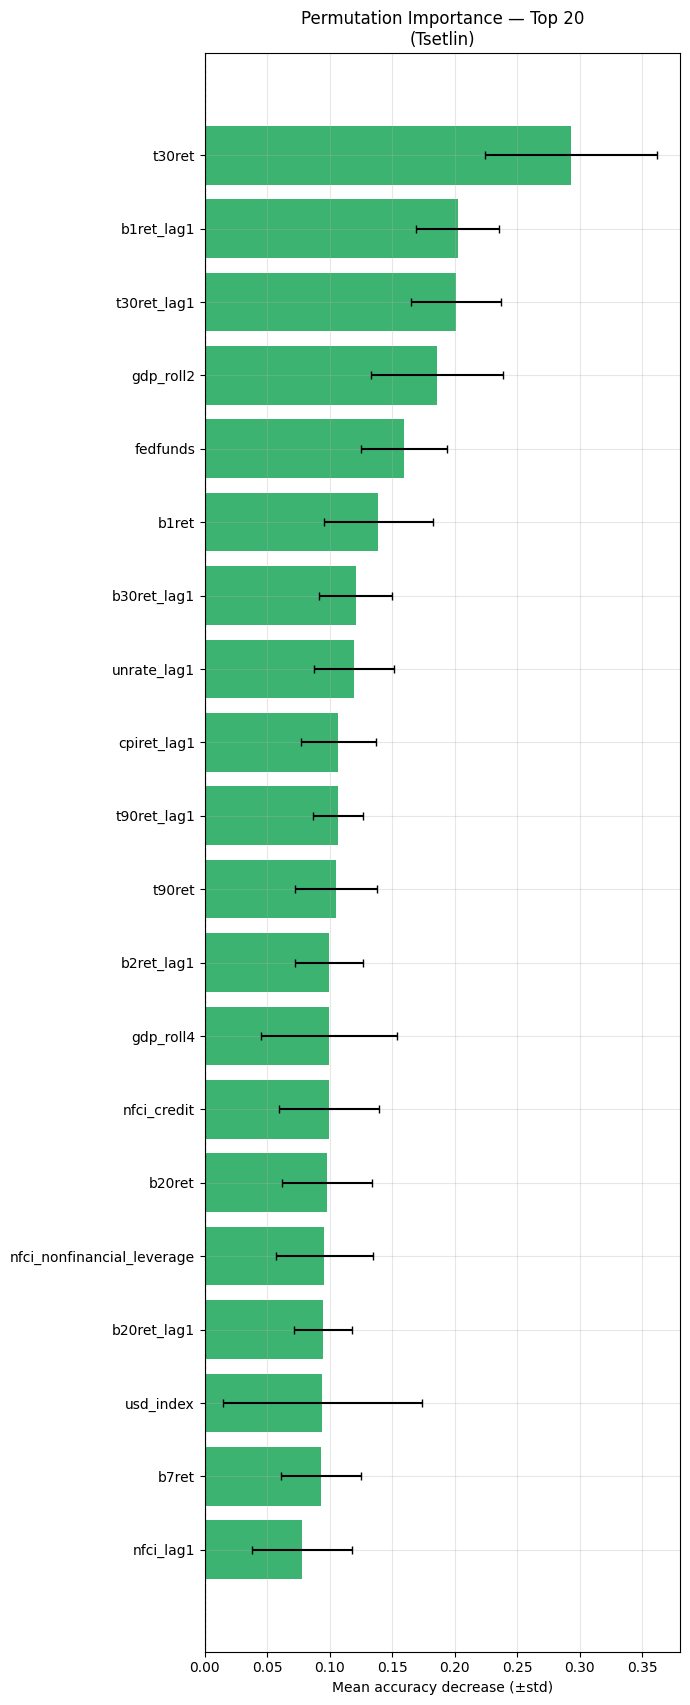

In [71]:
results, rmse, mape, r2, tsetlin_fi_perm = GDP_prediction(
    df, use_macro=True, model='tsetlin',
    use_scaling=False, test_quarters=8,
    tune=True, n_iter=30
)

Total: 136 | Train: 128 | Test: 8 | Features: 49

Tuning bayes with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.7914
  Best params: {'model__max_iter': 500, 'model__lambda_2': 1e-07, 'model__lambda_1': 1e-05, 'model__alpha_2': 1e-05, 'model__alpha_1': 1e-07}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.01
2023-06-30              0.01         0.02         0.01
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.02         0.01
2024-06-30              0.02         0.02         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.02         0.01
-----------------------------------------------------------------
                                        RMSE:       0.0063
                                    MAPE (%

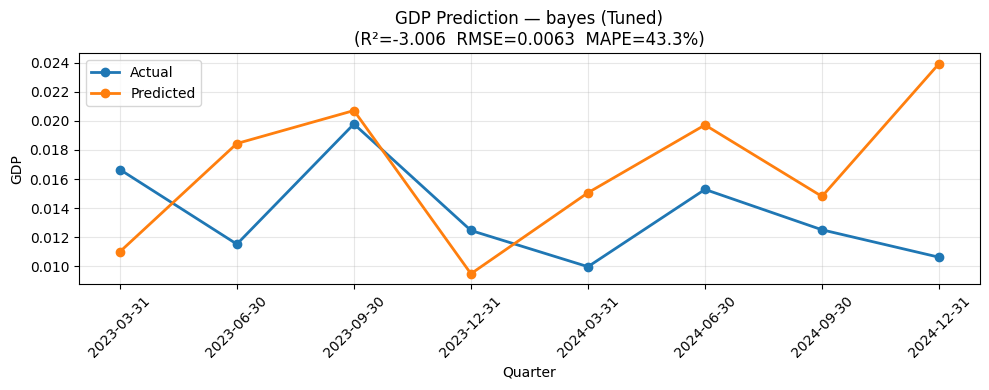

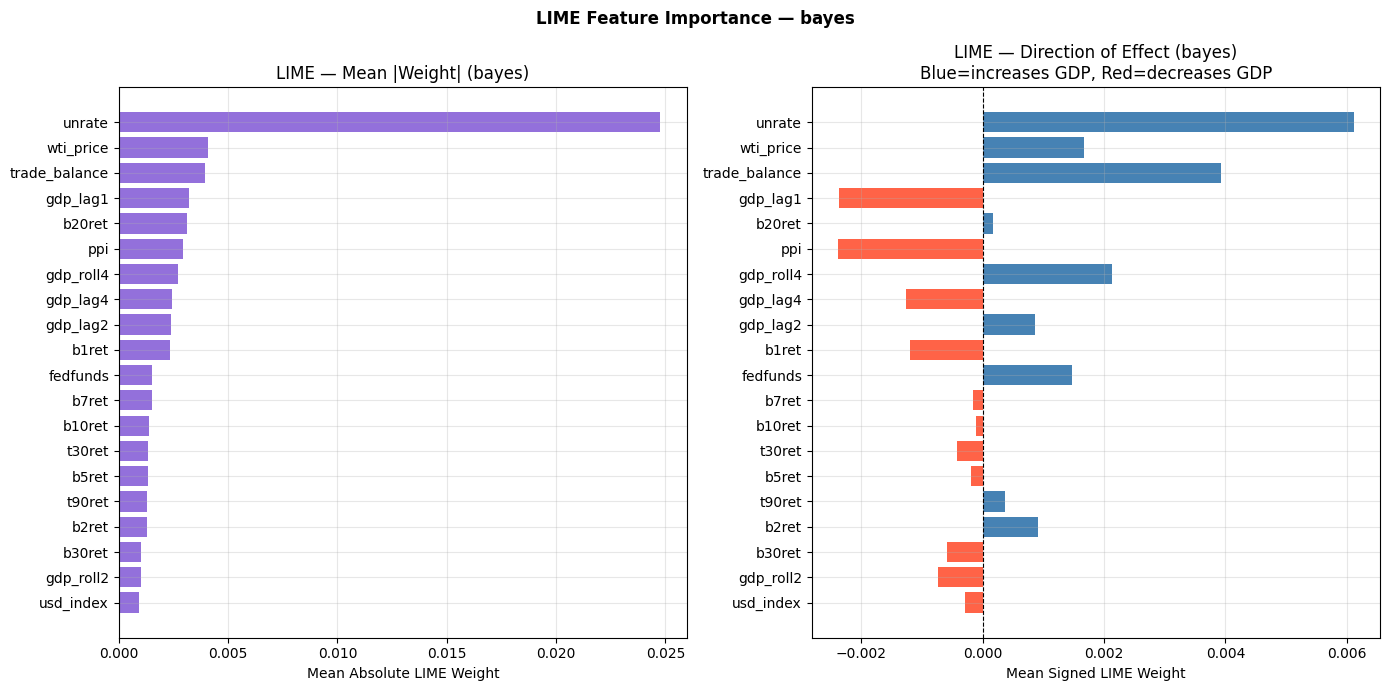

In [72]:
Results, rmse, mape, r2, bayes_fi_standard, bayes_fi_shap, bayes_fi_perm, bayes_f1_lime= GDP_prediction(
    df,
    use_macro=True,
    model='bayes',
    use_scaling=True,
    test_quarters=8,
    use_lags=True,
    use_rolling=True,
    feature_selection=False,
    importance_strategy='lime',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 49

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.01         0.00
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.01         0.00
2024-06-30              0.02         0.01         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.01         0.00
-----------------------------------------------------------------
                                        RMSE:       0.0030
                                    MAPE (%):        20.82
                                          R²:       0.1118


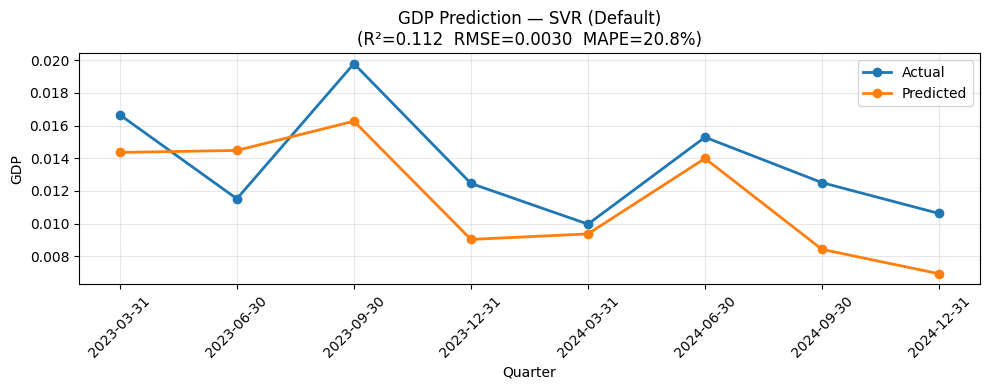

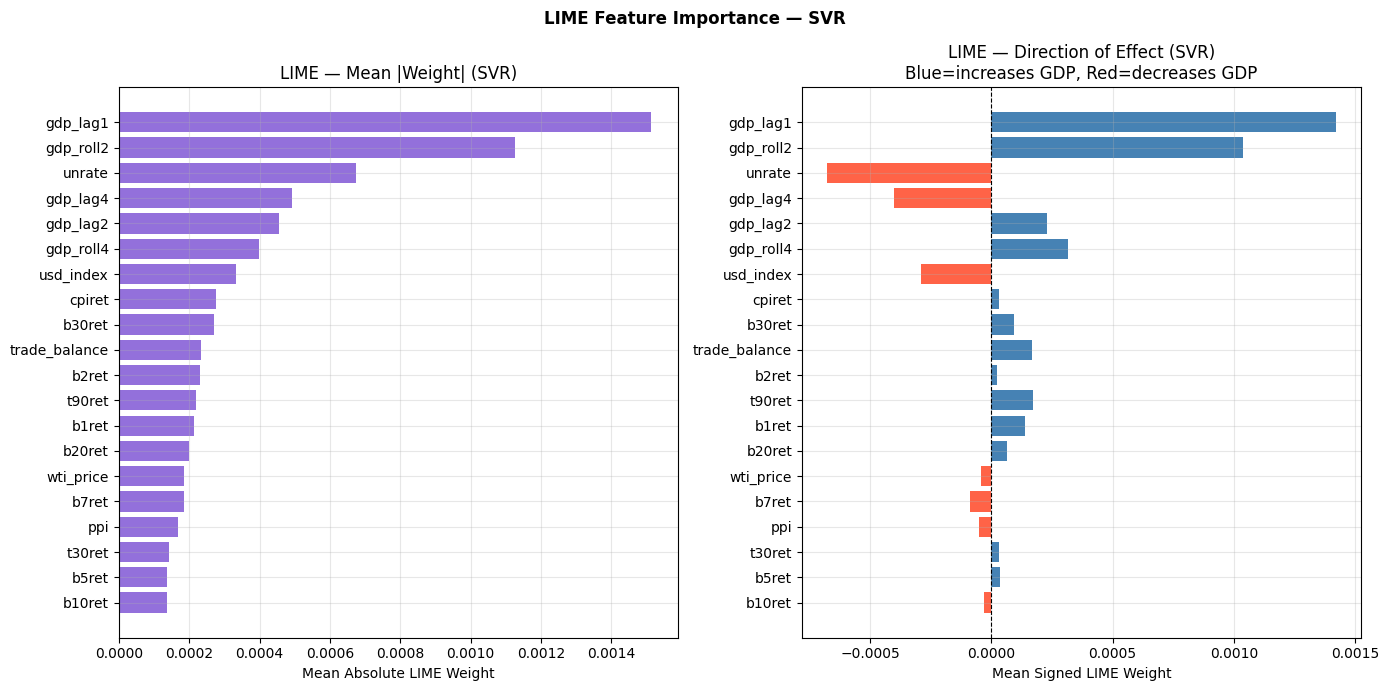

In [73]:
results, rmse, mape, r2, svr_fi_standard, svr_fi_shap, svr_fi_perm, svr_f1_lime = GDP_prediction(
    df,
    use_macro=True,
    model='SVR',
    use_scaling=True,
    test_quarters=8,
    feature_selection=False,
    importance_strategy='lime',
    tune=False, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 49

Tuning GB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.1970
  Best params: {'model__subsample': 0.6, 'model__n_estimators': 500, 'model__min_samples_leaf': 5, 'model__max_depth': 3, 'model__learning_rate': 0.03}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.00         0.02
2023-06-30              0.01         0.02         0.01
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01        -0.00         0.01
2024-03-31              0.01         0.00         0.01
2024-06-30              0.02         0.02         0.00
2024-09-30              0.01         0.02         0.01
2024-12-31              0.01         0.03         0.02
-----------------------------------------------------------------
                                        RMSE:       0.0118
                                    

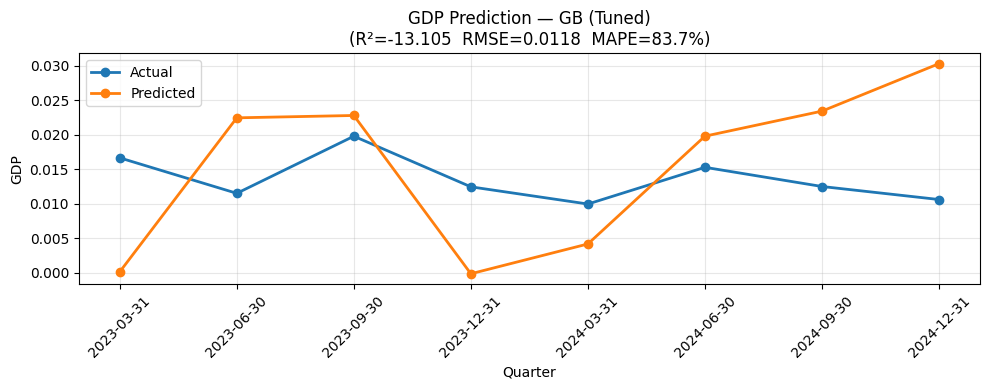

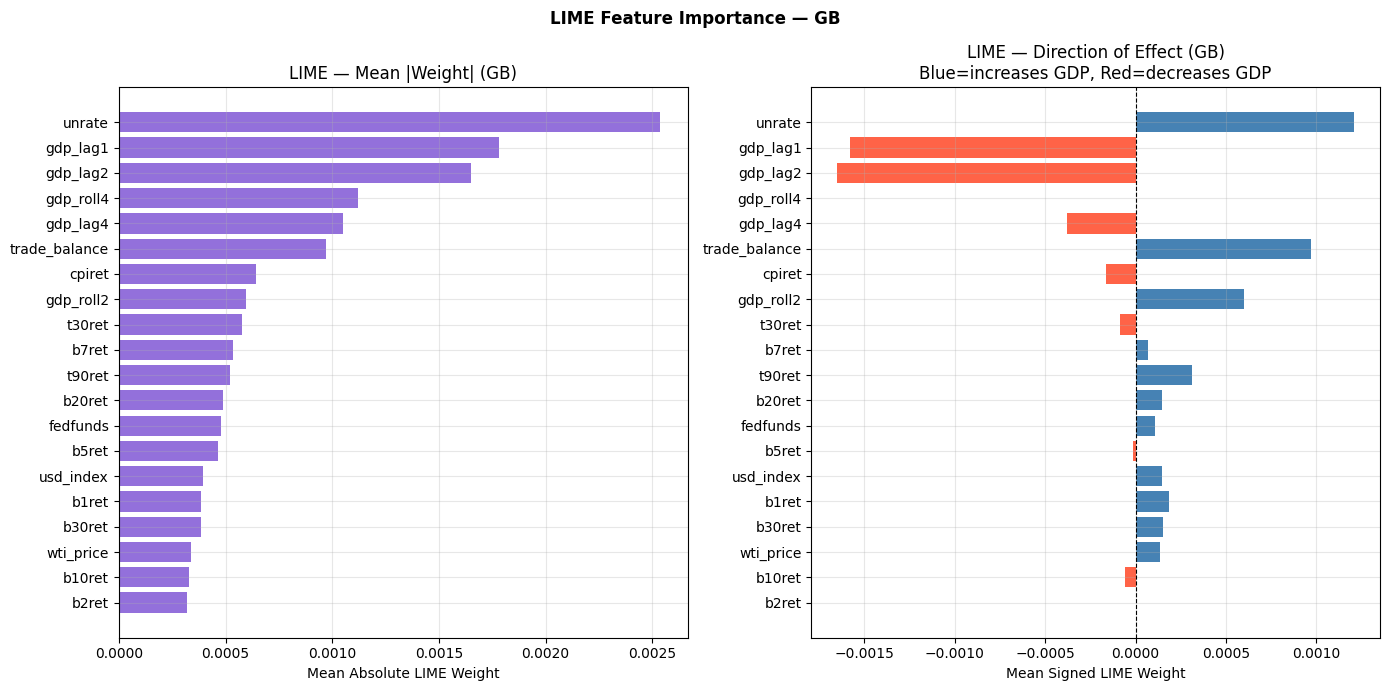

In [74]:
results, rmse, mape, r2, gb_fi_standard, gb_fi_shap, gb_fi_perm, gb_f1_lime= GDP_prediction(
    df,
    use_macro=True,
    model='GB',
    use_scaling=True,
    test_quarters=8,
    use_lags=True,
    use_rolling=True,
    feature_selection=False,
    importance_strategy='lime',
    tune=True, n_iter=30, cv_splits=5
)

Total: 136 | Train: 128 | Test: 8 | Features: 49

Tuning XGB with TimeSeriesSplit (n_iter=30, cv=5)...
  Best CV R²:  -0.1811
  Best params: {'model__subsample': 0.6, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.1, 'model__n_estimators': 800, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}

Date                  Actual    Predicted        Error
-----------------------------------------------------------------
2023-03-31              0.02         0.01         0.00
2023-06-30              0.01         0.02         0.01
2023-09-30              0.02         0.02         0.00
2023-12-31              0.01         0.01         0.00
2024-03-31              0.01         0.02         0.01
2024-06-30              0.02         0.02         0.00
2024-09-30              0.01         0.01         0.00
2024-12-31              0.01         0.02         0.01
-----------------------------------------------------------------
           

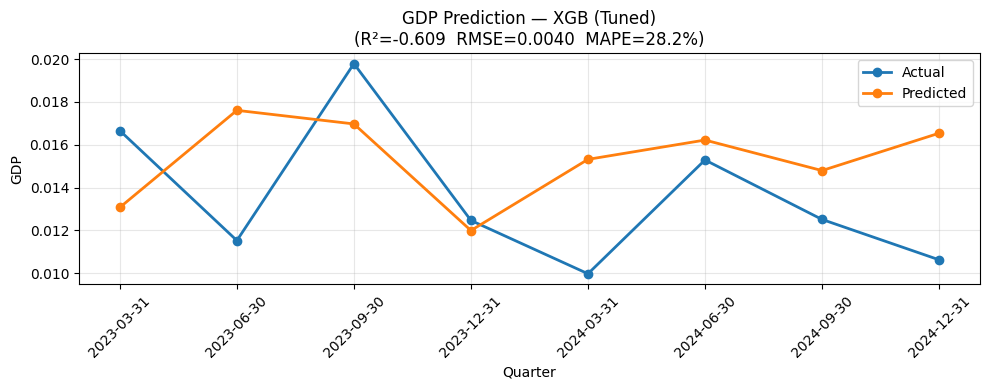

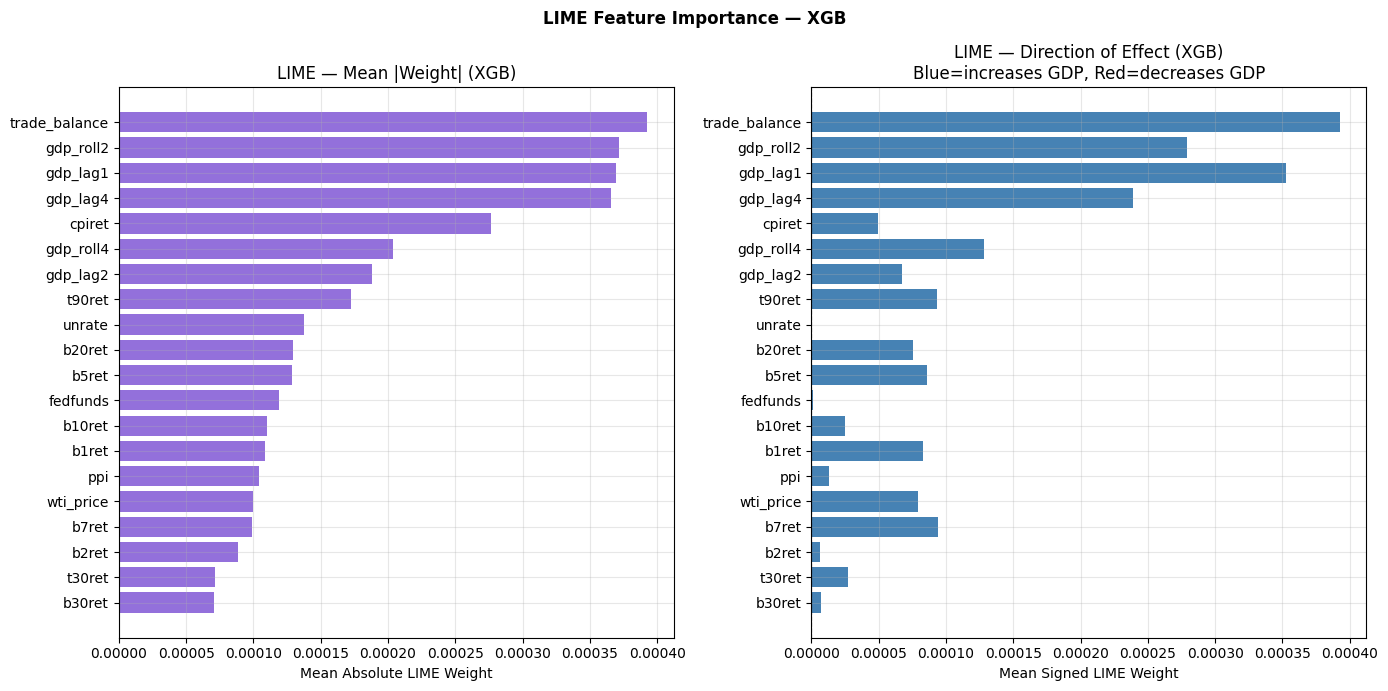

In [75]:
results, rmse, mape, r2, xgb_fi_standard, xgb_fi_shap, xgb_fi_perm, xgb_f1_lime= GDP_prediction(
    df,
    use_macro=True,
    model='XGB',
    use_scaling=True,
    test_quarters=8,
    use_lags=True,
    use_rolling=True,
    feature_selection=False,
    importance_strategy='lime',
    tune=True, n_iter=30, cv_splits=5
)

## Aggregate feature importance

In [76]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def aggregate_feature_importance(importance_results: dict,
                                  method: str = 'borda',
                                  top_n: int = 20) -> pd.DataFrame:

    model_names = list(importance_results.keys())
    n_models    = len(model_names)

    all_features = set()
    for fi_df in importance_results.values():
        all_features.update(fi_df['feature'].tolist())
    all_features = sorted(all_features)
    n_features   = len(all_features)

    rank_matrix  = pd.DataFrame(index=all_features, columns=model_names, dtype=float)
    score_matrix = pd.DataFrame(index=all_features, columns=model_names, dtype=float)

    for model_name, fi_df in importance_results.items():
        fi_df = fi_df.copy().reset_index(drop=True)
        fi_df['rank'] = fi_df['importance'].rank(ascending=False, method='min')

        imp_min = fi_df['importance'].min()
        imp_max = fi_df['importance'].max()
        denom   = imp_max - imp_min if imp_max != imp_min else 1.0
        fi_df['norm_score'] = (fi_df['importance'] - imp_min) / denom

        for _, row in fi_df.iterrows():
            rank_matrix.loc[row['feature'],  model_name] = row['rank']
            score_matrix.loc[row['feature'], model_name] = row['norm_score']


        missing = set(all_features) - set(fi_df['feature'])
        for f in missing:
            rank_matrix.loc[f,  model_name] = n_features + 1
            score_matrix.loc[f, model_name] = 0.0

    # Borda Count
    borda_scores = pd.Series(0.0, index=all_features)
    for model_name in model_names:
        borda_scores += (n_features + 1) - rank_matrix[model_name]

    borda_df = pd.DataFrame({
        'feature':     all_features,
        'borda_score': borda_scores.values,
        'borda_rank':  borda_scores.rank(ascending=False, method='min').astype(int)
    }).sort_values('borda_score', ascending=False).reset_index(drop=True)

    # Mean Rank
    mean_rank = rank_matrix.mean(axis=1)
    std_rank  = rank_matrix.std(axis=1)

    mean_rank_df = pd.DataFrame({
        'feature':   all_features,
        'mean_rank': mean_rank.values,
        'std_rank':  std_rank.values,
        'mean_rank_rank': mean_rank.rank(ascending=True, method='min').astype(int)
    }).sort_values('mean_rank').reset_index(drop=True)

    #  Mean Normalised Score
    mean_score = score_matrix.mean(axis=1)
    std_score  = score_matrix.std(axis=1)

    mean_score_df = pd.DataFrame({
        'feature':    all_features,
        'mean_score': mean_score.values,
        'std_score':  std_score.values,
        'mean_score_rank': mean_score.rank(ascending=False, method='min').astype(int)
    }).sort_values('mean_score', ascending=False).reset_index(drop=True)

    # Combined table
    combined = borda_df.merge(
        mean_rank_df[['feature', 'mean_rank', 'std_rank', 'mean_rank_rank']],
        on='feature'
    ).merge(
        mean_score_df[['feature', 'mean_score', 'std_score', 'mean_score_rank']],
        on='feature'
    )

    combined['consistency'] = 1 / (combined['std_rank'] + 1e-6)

    if method == 'borda':
        result = combined.sort_values('borda_score', ascending=False).reset_index(drop=True)
    elif method == 'mean_rank':
        result = combined.sort_values('mean_rank').reset_index(drop=True)
    elif method == 'mean_score':
        result = combined.sort_values('mean_score', ascending=False).reset_index(drop=True)
    else:
        result = combined.sort_values('borda_score', ascending=False).reset_index(drop=True)

    print(f"\n{'='*75}")
    print(f"AGGREGATED FEATURE IMPORTANCE — {method.upper()} ({n_models} models)")
    print(f"{'='*75}")
    print(f"{'Rank':<6} {'Feature':<35} {'Borda':>8} {'MeanRank':>10} {'MeanScore':>10} {'Consist.':>10}")
    print(f"{'-'*75}")
    for i, row in result.head(top_n).iterrows():
        print(f"{i+1:<6} {row['feature']:<35} "
              f"{row['borda_score']:>8.1f} "
              f"{row['mean_rank']:>10.2f} "
              f"{row['mean_score']:>10.4f} "
              f"{row['consistency']:>10.2f}")
    print(f"{'='*75}")

    _plot_aggregated(result, rank_matrix, score_matrix,
                     model_names, top_n, method)

    return result

In [77]:


def _plot_aggregated(result, rank_matrix, score_matrix,
                     model_names, top_n, method):

    top_features = result['feature'].head(top_n).tolist()
    n_plots      = 3
    fig, axes    = plt.subplots(1, n_plots, figsize=(7 * n_plots, max(5, top_n * 0.4)))

    top_borda = result.head(top_n)
    axes[0].barh(top_borda['feature'][::-1],
                 top_borda['borda_score'][::-1],
                 color='steelblue')
    axes[0].set_title("Borda Count Aggregation\n(higher = more important)")
    axes[0].set_xlabel("Borda Score")
    axes[0].grid(True, alpha=0.3)

    top_mr = result.sort_values('mean_rank').head(top_n)
    axes[1].barh(top_mr['feature'][::-1],
                 top_mr['mean_rank'][::-1],
                 xerr=top_mr['std_rank'][::-1],
                 color='darkorange', capsize=3)
    axes[1].set_title("Mean Rank Across Models\n(lower = more important, ±std)")
    axes[1].set_xlabel("Mean Rank")
    axes[1].invert_xaxis()
    axes[1].grid(True, alpha=0.3)

    heat_data = rank_matrix.loc[top_features].astype(float)
    im        = axes[2].imshow(heat_data.values, aspect='auto', cmap='RdYlGn_r')
    axes[2].set_xticks(range(len(model_names)))
    axes[2].set_xticklabels(model_names, rotation=45, ha='right')
    axes[2].set_yticks(range(len(top_features)))
    axes[2].set_yticklabels(top_features, fontsize=8)
    axes[2].set_title("Rank Heatmap per Model\n(green=important, red=less important)")
    plt.colorbar(im, ax=axes[2], label="Rank (1=most important)")

    for i in range(len(top_features)):
        for j in range(len(model_names)):
            axes[2].text(j, i, f"{int(heat_data.values[i, j])}",
                         ha='center', va='center', fontsize=7,
                         color='black')

    plt.suptitle(f"Feature Importance Aggregation — {method.upper()}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    top_consist = result.head(top_n).sort_values('std_rank')
    fig2, ax2   = plt.subplots(figsize=(8, max(4, top_n * 0.35)))
    colors      = ['green' if s < result['std_rank'].median() else 'salmon'
                   for s in top_consist['std_rank'][::-1]]
    ax2.barh(top_consist['feature'][::-1],
             top_consist['std_rank'][::-1],
             color=colors)
    ax2.axvline(result['std_rank'].median(), color='black',
                linestyle='--', linewidth=1, label='Median std')
    ax2.set_title("Rank Consistency Across Models\n"
                  "(lower std = consistently important, green = robust)")
    ax2.set_xlabel("Std of Rank (across models)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [78]:

def plot_model_agreement(importance_results: dict, top_n: int = 10):
    model_names  = list(importance_results.keys())
    vote_counts  = {}

    for model_name, fi_df in importance_results.items():
        top_features = fi_df.nlargest(top_n, 'importance')['feature'].tolist()
        for f in top_features:
            vote_counts[f] = vote_counts.get(f, 0) + 1

    vote_df = pd.DataFrame({
        'feature': list(vote_counts.keys()),
        'votes':   list(vote_counts.values())
    }).sort_values('votes', ascending=False).reset_index(drop=True)

    print(f"\n{'='*55}")
    print(f"MODEL AGREEMENT — Top {top_n} features per model")
    print(f"{'='*55}")
    for _, row in vote_df.iterrows():
        bar   = '█' * row['votes']
        pct   = row['votes'] / len(model_names) * 100
        print(f"  {row['feature']:<30} {bar:<10} {row['votes']}/{len(model_names)} ({pct:.0f}%)")
    print(f"{'='*55}")

    fig, ax = plt.subplots(figsize=(8, max(4, len(vote_df) * 0.35)))
    colors  = ['darkgreen' if v == len(model_names)
               else 'steelblue' if v >= len(model_names) * 0.6
               else 'salmon'
               for v in vote_df['votes'][::-1]]
    ax.barh(vote_df['feature'][::-1], vote_df['votes'][::-1], color=colors)
    ax.axvline(len(model_names), color='black', linestyle='--',
               linewidth=1, label=f'All {len(model_names)} models')
    ax.axvline(len(model_names) * 0.6, color='orange', linestyle='--',
               linewidth=1, label=f'60% of models')
    ax.set_xlabel(f"Number of models featuring in top {top_n}")
    ax.set_title(f"Feature Agreement Across Models\n"
                 f"(green = in top {top_n} of ALL models)")
    ax.set_xlim(0, len(model_names) + 0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return vote_df


AGGREGATED FEATURE IMPORTANCE — MEAN_RANK (3 models)
Rank   Feature                                Borda   MeanRank  MeanScore   Consist.
---------------------------------------------------------------------------
1      gdp_lag1                               141.0       3.00     0.5908       1.00
2      trade_balance                          140.0       3.33     0.5136       0.40
3      unrate                                 139.0       3.67     0.7833       0.22
4      gdp_lag4                               133.0       5.67     0.4815       0.48
5      gdp_roll4                              133.0       5.67     0.3569       0.65
6      gdp_lag2                               131.0       6.33     0.4087       0.33
7      b20ret                                 123.0       9.00     0.2158       0.28
8      gdp_roll2                              121.0       9.67     0.4076       0.12
9      cpiret                                 117.0      11.00     0.3302       0.11
10     t90ret       

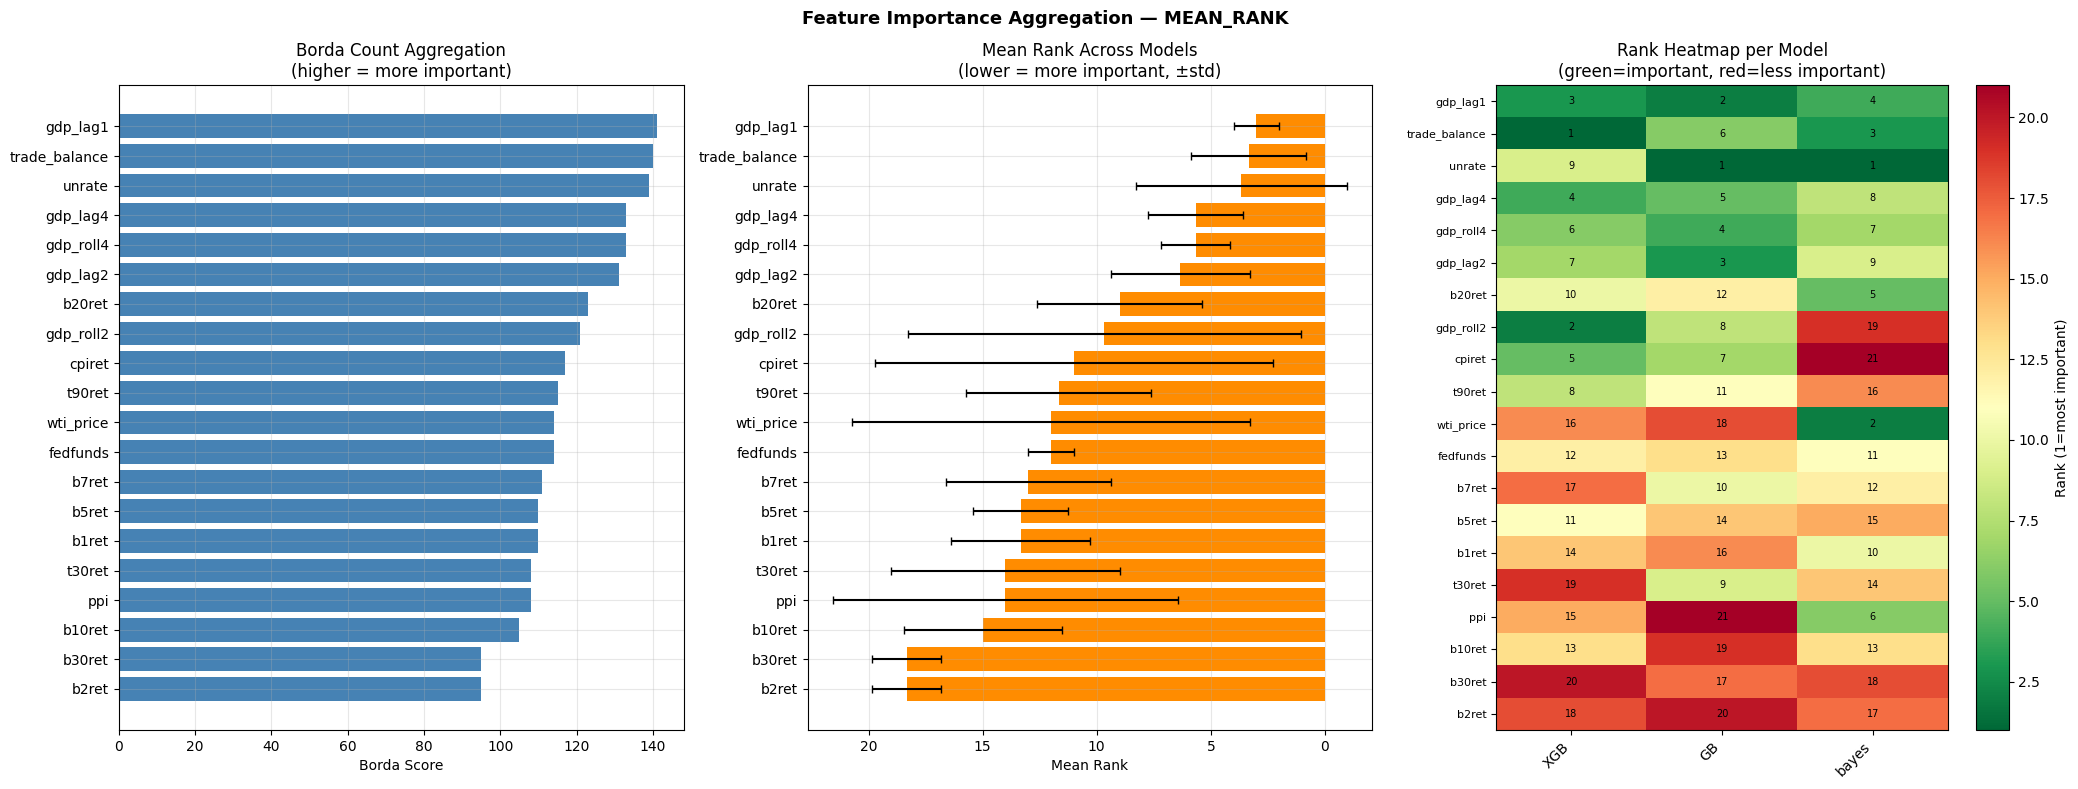

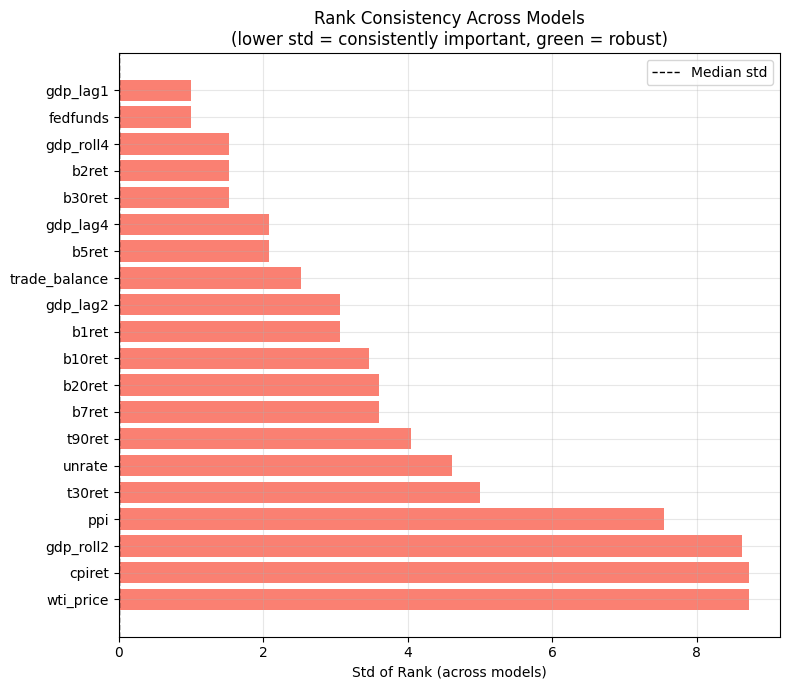


MODEL AGREEMENT — Top 10 features per model
  trade_balance                  ███        3/3 (100%)
  gdp_lag1                       ███        3/3 (100%)
  gdp_lag4                       ███        3/3 (100%)
  gdp_lag2                       ███        3/3 (100%)
  gdp_roll4                      ███        3/3 (100%)
  unrate                         ███        3/3 (100%)
  gdp_roll2                      ██         2/3 (67%)
  cpiret                         ██         2/3 (67%)
  b20ret                         ██         2/3 (67%)
  t90ret                         █          1/3 (33%)
  t30ret                         █          1/3 (33%)
  b7ret                          █          1/3 (33%)
  wti_price                      █          1/3 (33%)
  ppi                            █          1/3 (33%)
  b1ret                          █          1/3 (33%)


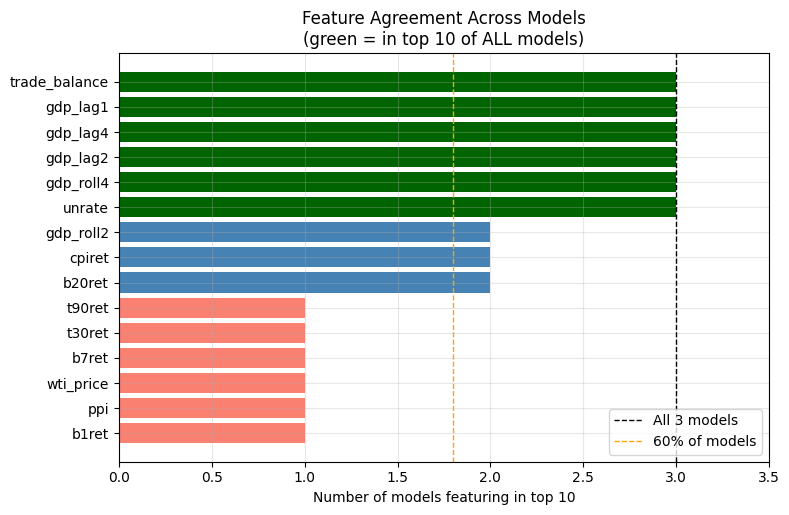

In [80]:
importance_results = {
    'XGB':      xgb_f1_lime,
    'GB':       gb_f1_lime,
    'bayes':    bayes_f1_lime
}

aggregated = aggregate_feature_importance(
    importance_results,
    method = 'mean_rank',    # 'borda', 'mean_rank', 'mean_score', 'all'
    top_n  = 20
)

vote_df = plot_model_agreement(importance_results, top_n=10)